In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_rdm_dem.csv").dropna()
participantcode = data.participant.unique()
data["confidence"] = data["confidence"]*0.1
data["confidence"] = data["confidence"].astype(theano.config.floatX)

In [4]:
fig = px.violin(data, y='confidence',x="coherence", color='session',
                   orientation='v',
                violinmode='overlay',
                   labels={'confidence': 'confidence',
                            'acc': 'Response'},
                   width=1733,
                   height=900)

fig.show()

In [5]:
fig = px.histogram(data, x="confidence",
                   histnorm='probability density',
                   orientation='v',
                   labels={'draws': 'conf',
                            'acc': 'Response'},
                   barmode='overlay',
                   width=1733,
                   height=900)

fig.show()

In [5]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

median_conf=data["confidence"].median()
hr_conf= pm.Model(coords=coords) 

with hr_conf:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0, sigma=100,testval=0.0)
    sigma_a = pm.HalfNormal("sigma_a", 5,testval=1)
    mu_beta_tms = pm.Normal("mu_beta_tms", mu=0, sigma=100)
    sigma_b_tms = pm.HalfNormal("sigma_b_tms", 5)
    mu_beta_coh = pm.Normal("mu_beta_coherence", mu=0, sigma=100)
    sigma_b_coh = pm.HalfNormal("sigma_b_coherence", 5)
    mu_beta_caps = pm.Normal("mu_beta_caps", mu=0, sigma=100)
    sigma_b_caps = pm.HalfNormal("sigma_b_caps", 5)
    mu_beta_cohXcaps = pm.Normal("mu_beta_coherenceXcaps", mu=0, sigma=100)
    sigma_b_cohXcaps = pm.HalfNormal("sigma_b_coherenceXcaps", 5)
    mu_beta_tmsXcaps = pm.Normal("mu_beta_tmsXcaps", mu=0, sigma=100)
    sigma_b_tmsXcaps = pm.HalfNormal("sigma_b_tmsXcaps", 5)


    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect tms  
    b = pm.Normal("b", mu=mu_beta_tms, sigma=sigma_b_tms, dims="participant")
    # effect coherence
    b_coh = pm.Normal("b_coh", mu=mu_beta_coh, sigma=sigma_b_coh, dims="participant")
     # effect coherence
    b_caps = pm.Normal("b_caps", mu=mu_beta_caps, sigma=sigma_b_caps, dims="participant")
    # effect interaction 
    b_cohXcaps = pm.Normal("b_cohXcaps", mu=mu_beta_cohXcaps, sigma=sigma_b_cohXcaps, dims="participant")
    b_tmsXcaps = pm.Normal("b_tmsXcaps", mu=mu_beta_tmsXcaps, sigma=sigma_b_tmsXcaps, dims="participant")


    # Model spec
    eps = pm.HalfCauchy("eps", 5)
    confidence_est = (a[participant_idx] 
                      + b[participant_idx] * data.session.values
                      +b_coh[participant_idx] * data.coherence.values                      
                      +b_caps[participant_idx] * data.caps.values
                      +b_cohXcaps[participant_idx] * data.coherence.values * data.caps.values
                      +b_tmsXcaps[participant_idx] * data.caps.values * data.session.values)

    # Data likelihood
    confidence_like = pm.Normal(
        "confidence_like", mu=confidence_est, sigma=eps, observed=data.confidence, dims="obs_id",testval=median_conf)
    
    

In [6]:
with hr_conf:
    hr_conf_trace = pm.sample(5000,tune=5000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b_tmsXcaps, b_cohXcaps, b_caps, b_coh, b, a, sigma_b_tmsXcaps, mu_beta_tmsXcaps, sigma_b_coherenceXcaps, mu_beta_coherenceXcaps, sigma_b_caps, mu_beta_caps, sigma_b_coherence, mu_beta_coherence, sigma_b_tms, mu_beta_tms, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 1708 seconds.


0, dim: obs_id, 2718 =? 2718


There were 365 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.8376815953389354, but should be close to 0.9. Try to increase the number of tuning steps.
There were 148 divergences after tuning. Increase `target_accept` or reparameterize.
There were 224 divergences after tuning. Increase `target_accept` or reparameterize.
There were 806 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.812812772874553, but should be close to 0.9. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.


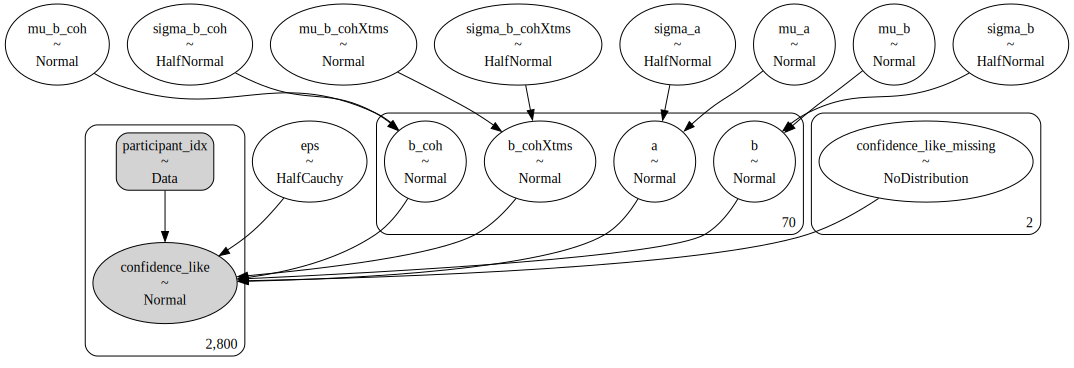

In [4]:
pm.model_to_graphviz(hr_conf)

In [7]:
# Save the model
with open('hr_conf_tmsXcondxcaps.pkl', 'wb') as file:
    pickle.dump(hr_conf, file)
    
hr_conf_trace.to_netcdf('hr_conf_tmsXcondxcaps_traces.nc', compress=False)    

'hr_conf_tmsXcondxcaps_traces.nc'

In [4]:
# Load the model from the pickled file
with open('hr_conf_tmsXcondxcaps.pkl', 'rb') as file:
    hr_conf = pickle.load(file)

hr_conf_trace = az.from_netcdf('hr_conf_tmsXcondxcaps_traces.nc')


In [5]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_conf_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_conf_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_conf_trace).waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(2499.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:          ()
Data variables:
    confidence_like  float64 2.919e+07
Effective number of parameters (p_waic): 104.83691075365437
WAIC: 1405.068936664904


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



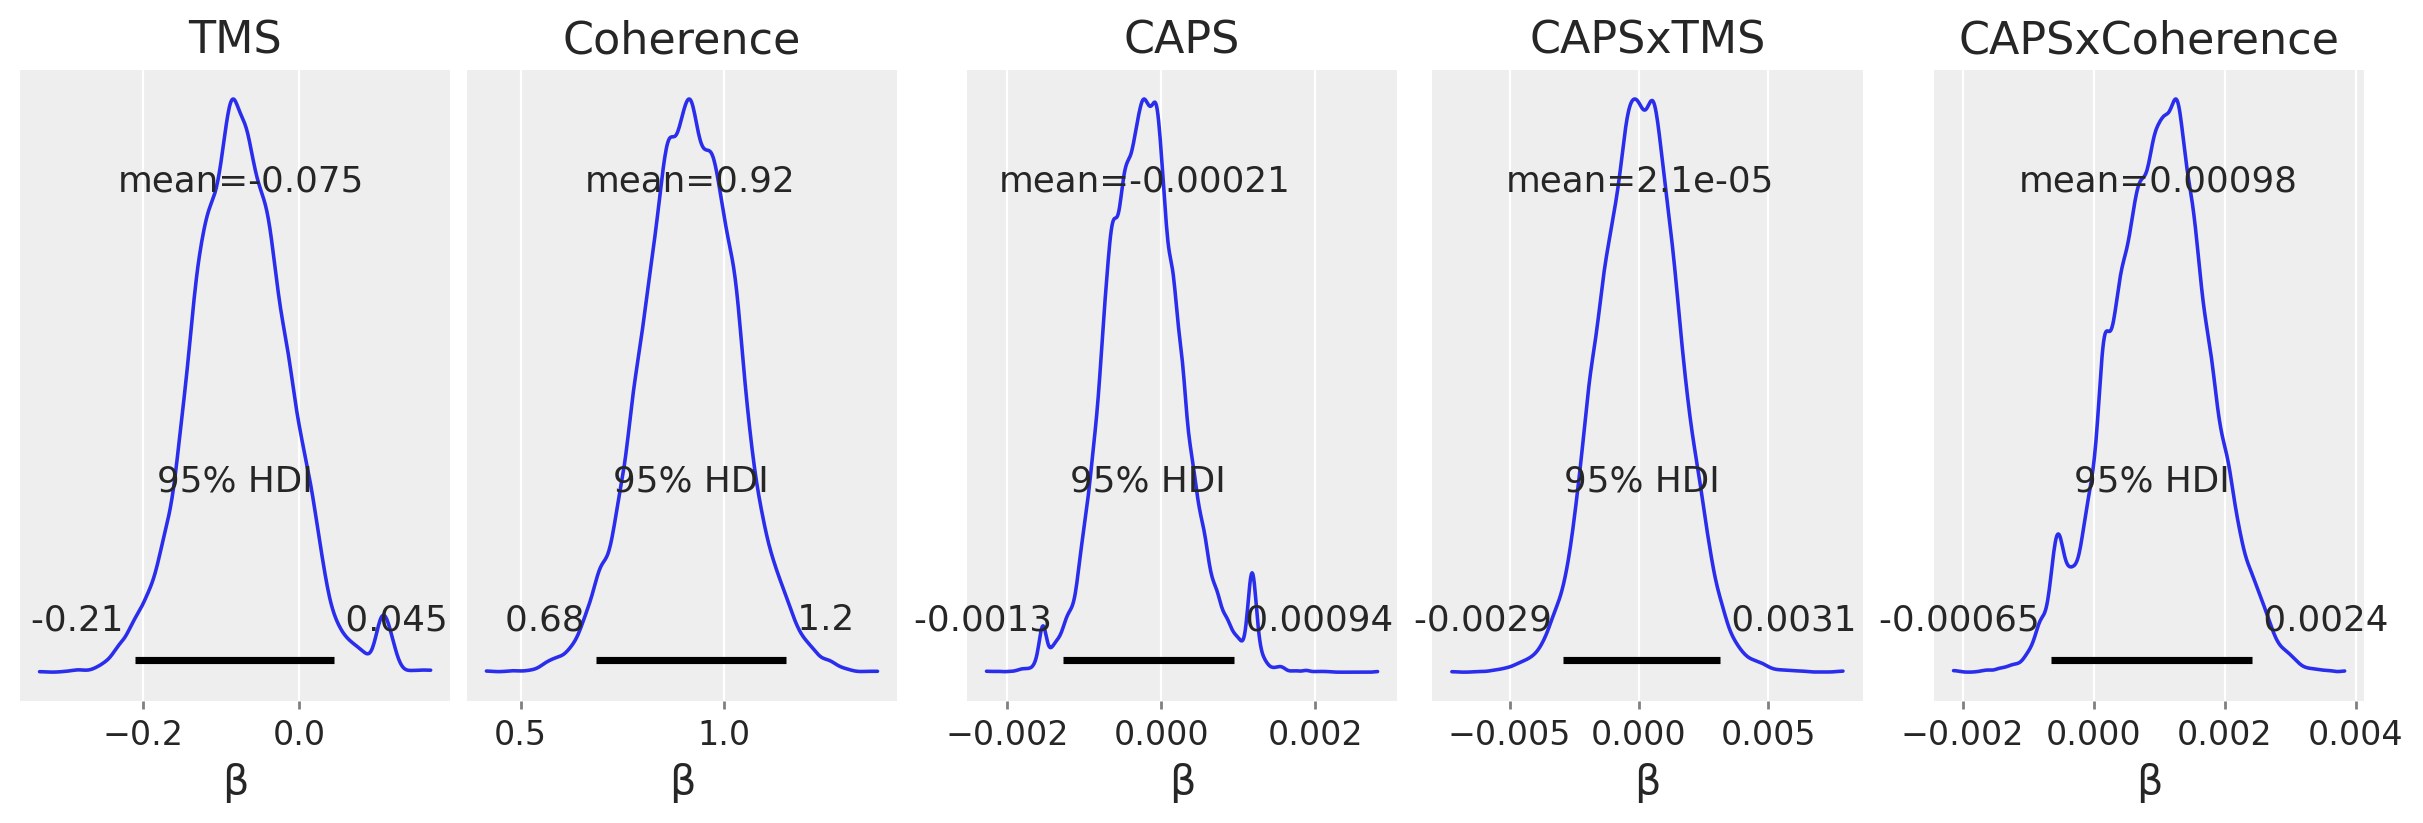

<Figure size 1200x400 with 0 Axes>

In [42]:
plot=az.plot_posterior(hr_conf_trace, var_names=["mu_beta_tms", "mu_beta_coherence","mu_beta_caps", "mu_beta_coherenceXcaps","mu_beta_tmsXcaps"],
                       grid={5,1},
                       hdi_prob=0.95,
                       textsize=12, 
                       figsize={12, 4});                     

# Set the DPI for high resolution
dpi = 300

# Get the axes from the plot
axes = plot.ravel()

# Create a new Figure and specify the spacing between subplots
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(5, 1, hspace=0.4)  # Customize hspace as needed

# Add the existing axes to the new Figure

for i in range(5):
    ax = axes[i]
    ax.set_xlabel("β")  # Set the custom y-axis label here

# Set the titles for each subplot
titles = ["TMS", "Coherence", "CAPS", "CAPSxTMS", "CAPSxCoherence"]

# Loop through each subplot and set the title
for i, ax in enumerate(plot.ravel()):
    ax.set_title(titles[i])
    
# Get the figure object
fig = plot.ravel()[0].figure
   
# Save the image with high resolution
fig.savefig("supl_study2_mu_b_capsxtmsXcond_traces.png", dpi=dpi)



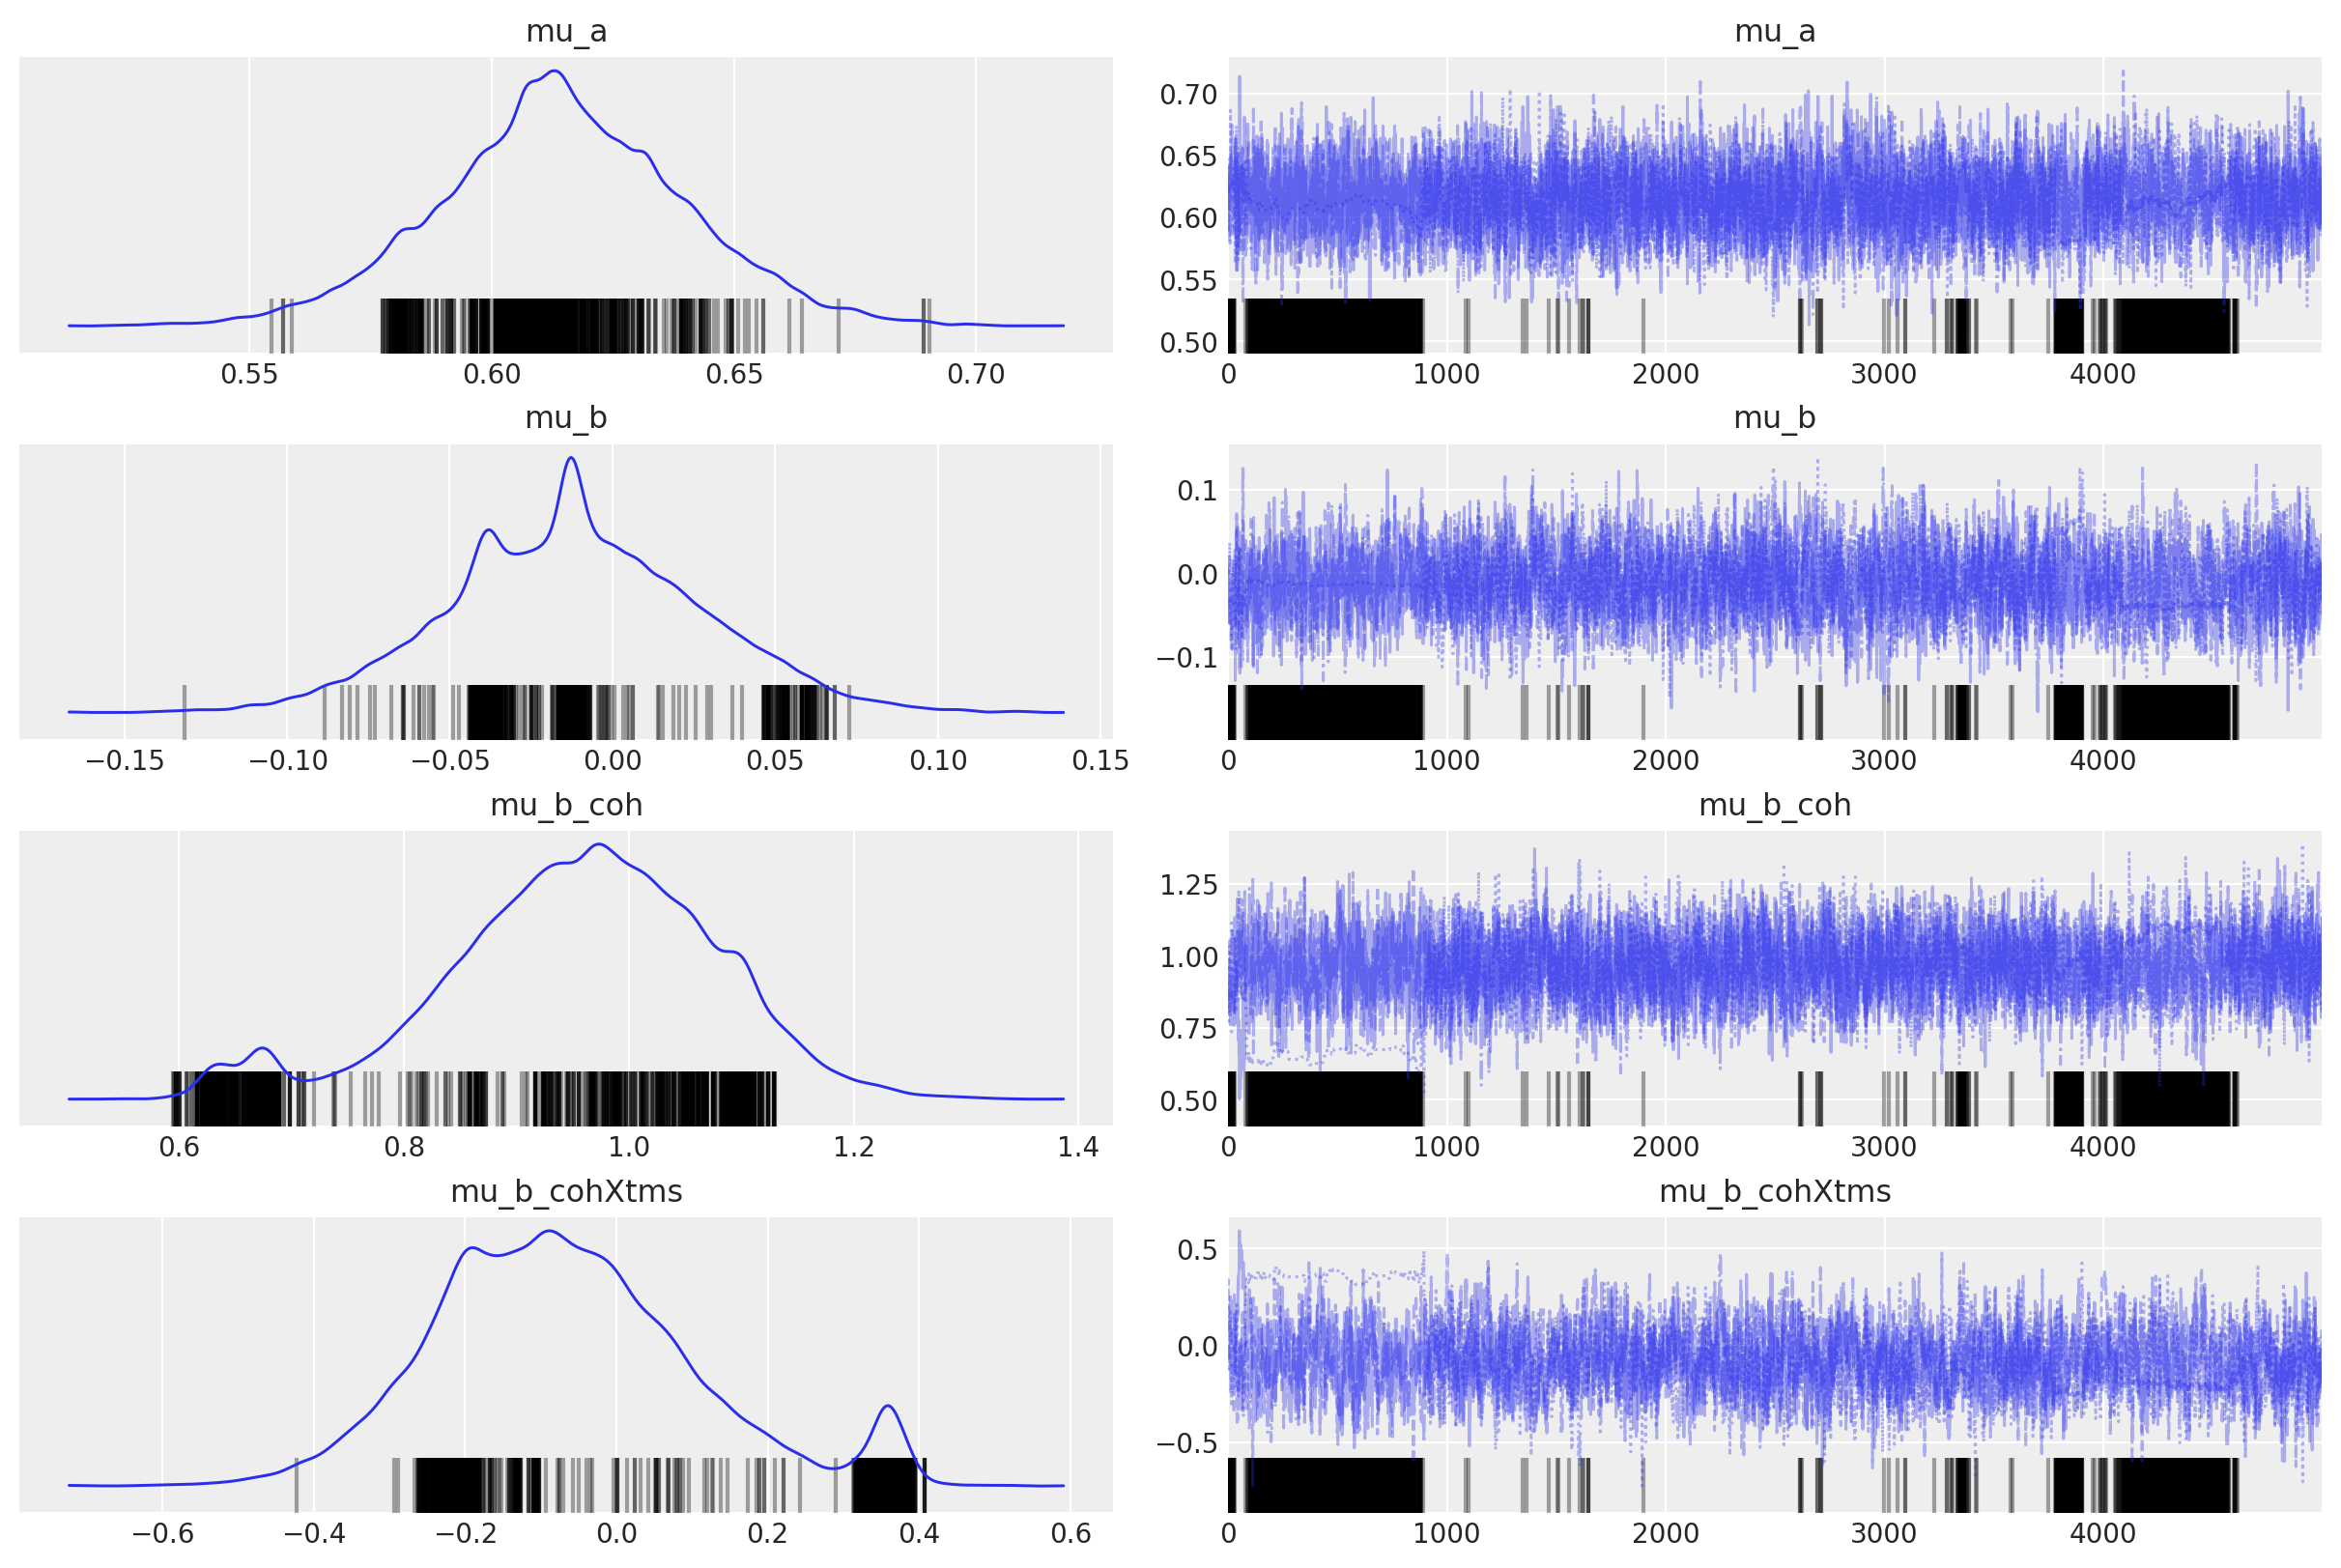

In [35]:
az.plot_trace(hr_conf_trace, var_names=["mu_a", "mu_beta", "mu_beta_coh","mu_beta_cohXtms"],
             combined=True,
             coords={"participant": participant});


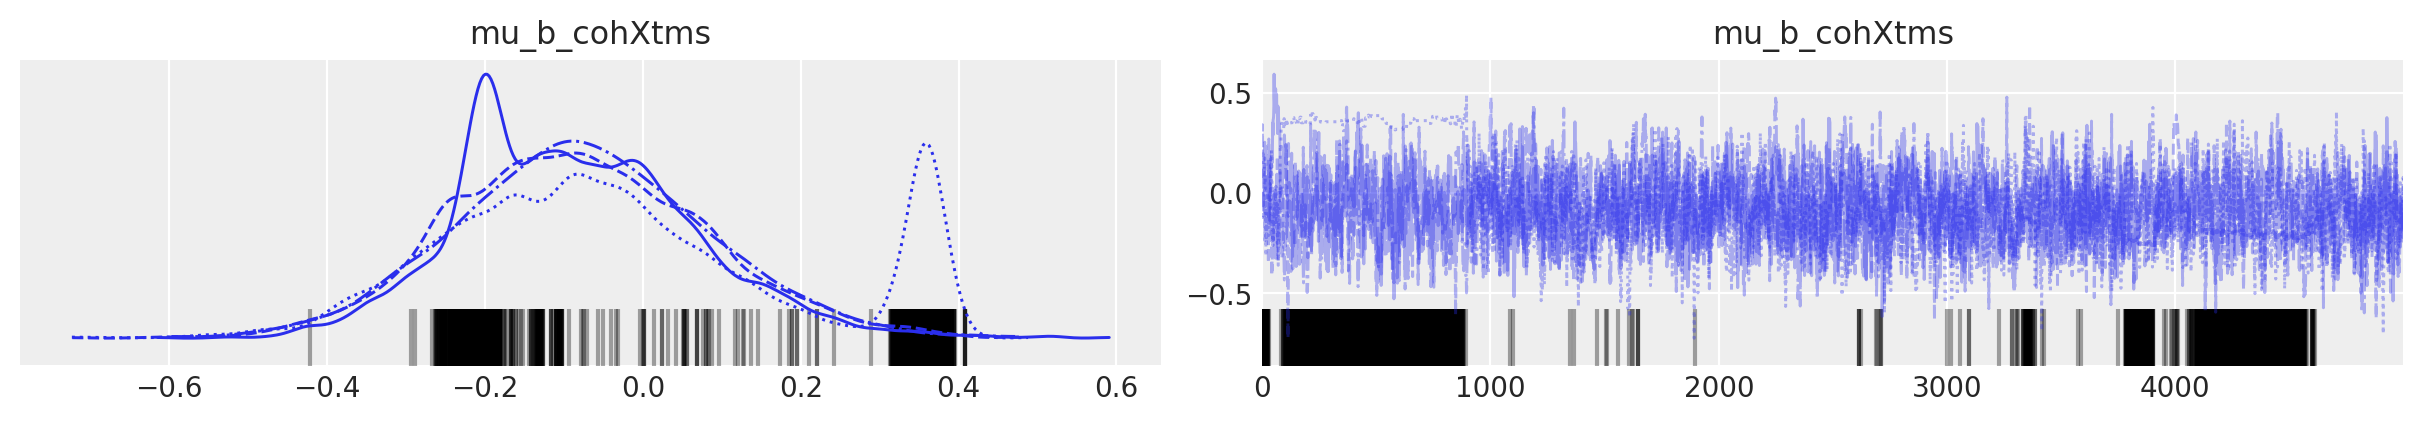

In [10]:
az.plot_trace(hr_conf_trace, var_names=["mu_beta_cohXtms"]);


ValueError: not enough values to unpack (expected 2, got 1)

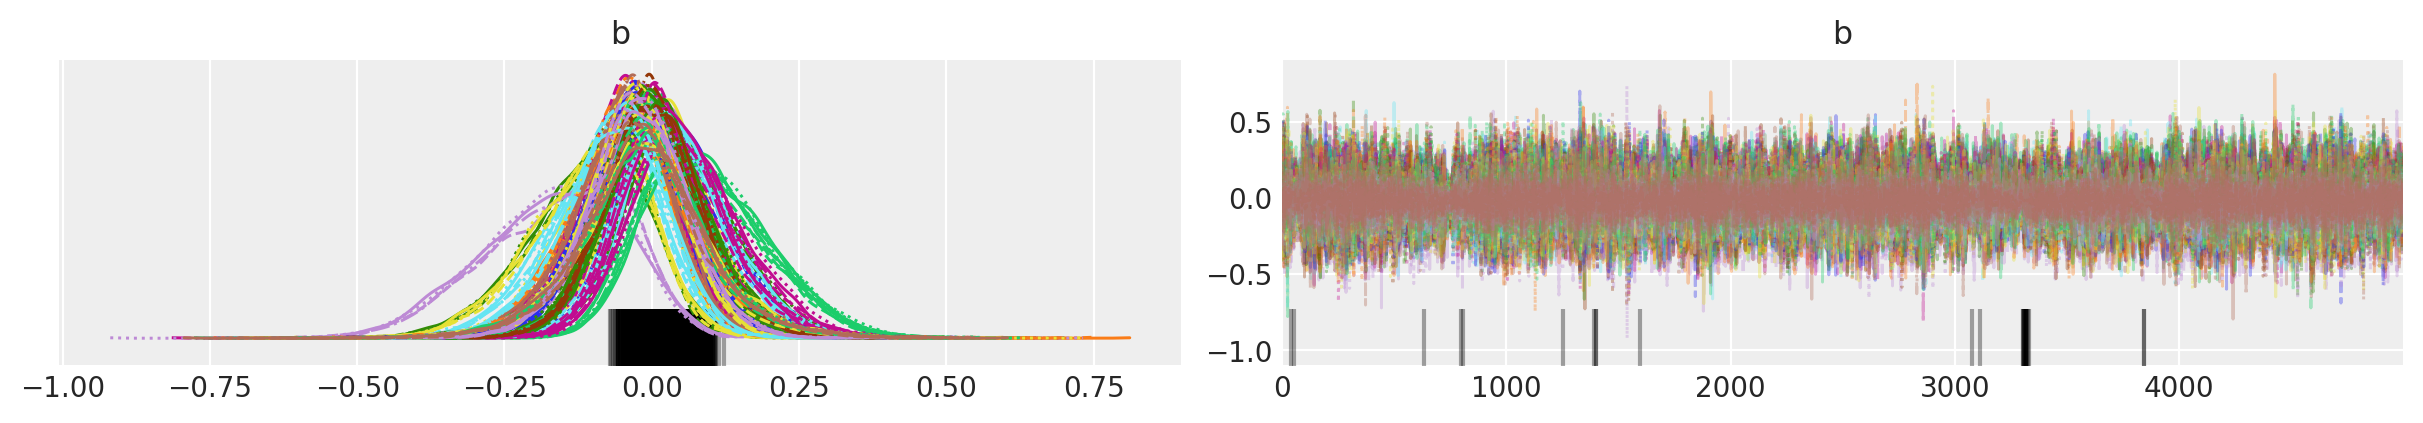

In [12]:
fig, b_trace_conf=az.plot_trace(hr_conf_trace, var_names=["b"], coords={"participant": participant});
b_trace_conf.save("b_trace_conf.jpg")

In [11]:
stat_tms_reg=pm.summary(hr_conf_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.614,0.025,0.566,0.662,0.000,0.000,3182.0,5822.0,1.01
mu_b,-0.012,0.039,-0.083,0.063,0.001,0.001,1999.0,2109.0,1.03
mu_b_coh,0.954,0.122,0.671,1.158,0.015,0.011,98.0,18.0,1.03
mu_b_cohXtms,-0.068,0.177,-0.342,0.361,0.021,0.015,110.0,18.0,1.03
a[0],0.565,0.084,0.401,0.720,0.002,0.001,2932.0,1616.0,1.01
...,...,...,...,...,...,...,...,...,...
sigma_a,0.142,0.018,0.108,0.172,0.001,0.001,439.0,4424.0,1.01
sigma_b,0.085,0.047,0.007,0.158,0.005,0.003,73.0,24.0,1.04
sigma_b_coh,0.423,0.097,0.233,0.596,0.005,0.004,324.0,1482.0,1.02
sigma_b_cohXtms,0.282,0.164,0.027,0.556,0.014,0.010,121.0,102.0,1.05


In [5]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

median_conf=data["confidence"].median()
hr_null= pm.Model(coords=coords) 

with hr_null:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=median_conf, sigma=5,testval=0.0)
    sigma_a = pm.HalfNormal("sigma_a", 5,testval=1)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect tms  
    

    # Model spec
    eps = pm.HalfCauchy("eps", 5)
    confidence_est_null = (a[participant_idx] 
                      )

    # Data likelihood
    confidence_like_null = pm.Normal(
        "confidence_like_null", mu=confidence_est_null, sigma=eps, observed=data.confidence, dims="obs_id",testval=median_conf)
    
with hr_null:
    hr_null_trace = pm.sample(5000,tune=5000, target_accept=0.9, return_inferencedata=True) 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, a, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 78 seconds.


0, dim: obs_id, 2718 =? 2718


In [13]:
# Assuming you have already defined and sampled your PyMC3 model (hr_conf_trace)
# Calculate the WAIC
waic = pm.waic(hr_conf_trace)

waic_null = pm.waic(hr_null_trace)

# Get the log marginal likelihood from WAIC
marginal_likelihood_null = waic_null.waic

# Get the log marginal likelihood from WAIC
marginal_likelihood_conf = waic.waic

# Calculate the Bayes Factor using the log marginal likelihoods
BF_smc = marginal_likelihood_conf/marginal_likelihood_null

# Optionally, you can round the Bayes Factor for better readability
rounded_BF_smc = np.round(BF_smc, 2)

print(rounded_BF_smc)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



1.12


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



In [64]:
b_mu_reg=stat_tms_reg.loc['mu_beta']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_beta']['sd']

In [65]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.05))
print (b_tms)

OVL Beta TMS vs O
0.7957121648293113


In [66]:
conf_1=trace_groups.get_values(varname="mu", chains=1)
conf_1=pd.DataFrame(conf_1)

NameError: name 'trace_groups' is not defined

In [6]:
with hr_conf:
    posterior_pred= pm.sample_posterior_predictive(
        hr_conf_trace, var_names=["a", "b", "b_coh","b_caps", "b_cohXcaps","b_tmsXcaps","confidence_like"]
    )

In [7]:
observed_data = data['confidence']  # Replace with your actual observed data
predicted_data=np.abs(posterior_pred['confidence_like'])
deviances = -2 * np.sum(np.log(predicted_data), axis=1)

pD = np.mean(deviances) - deviances.mean()
DIC = pD + np.mean(deviances)
print (DIC)

2269.0605329566038


<Axes: xlabel='confidence_like'>

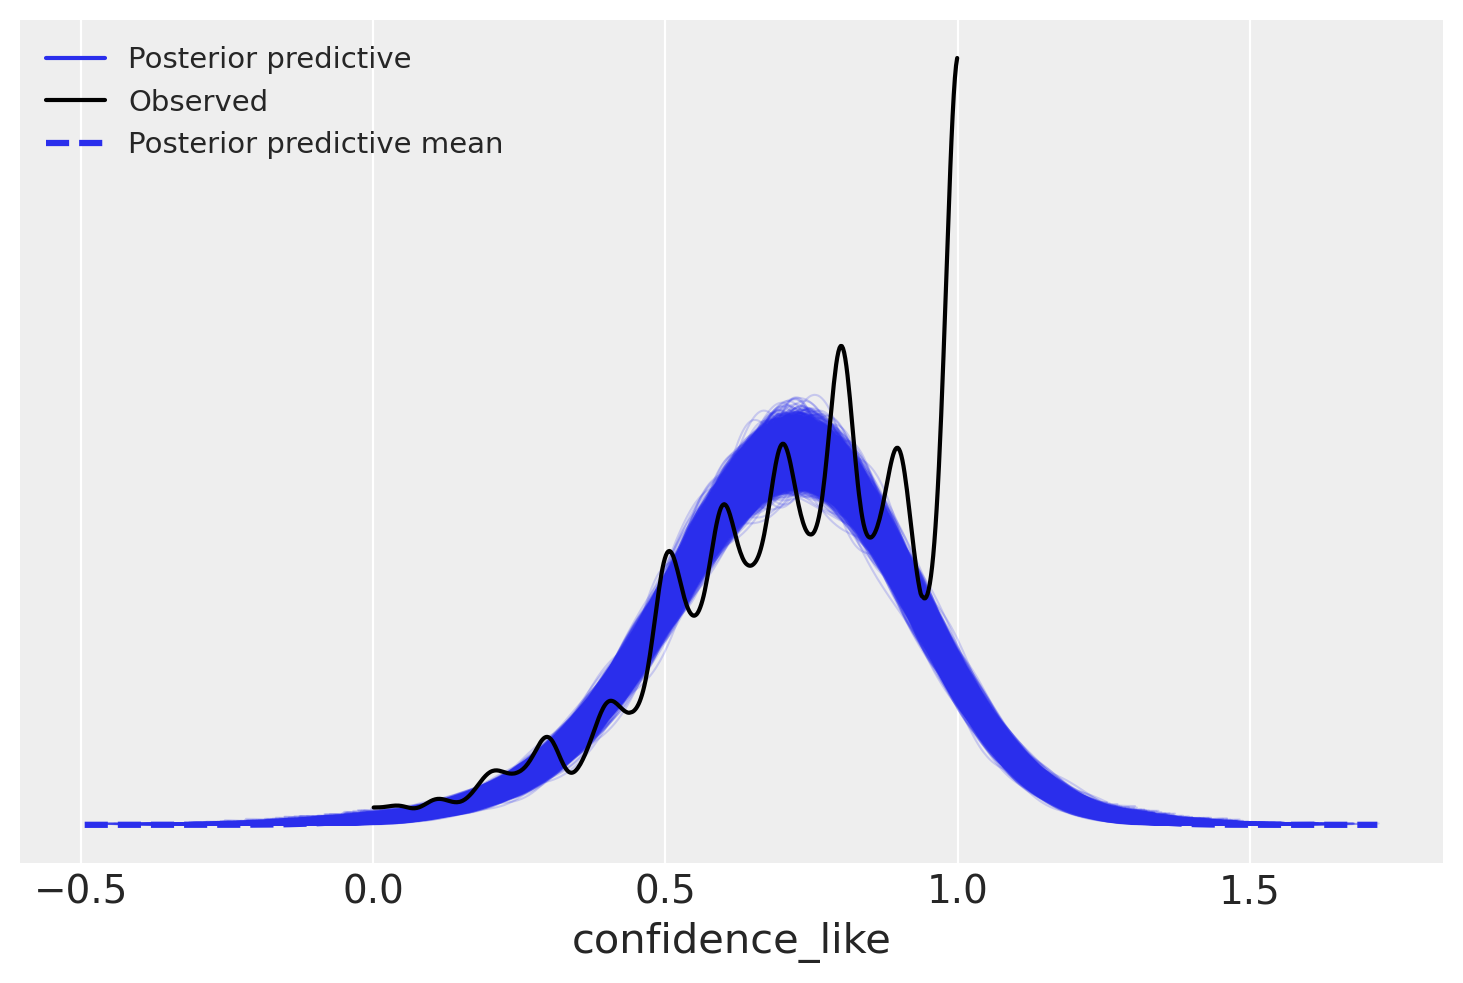

In [68]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_conf))